In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import GridSearchCV
import math


Loading the Dataset

In [151]:
train_df=pd.read_csv("Dataset/train.csv")
test_df=pd.read_csv("Dataset/test.csv")

In [152]:
print("TRAIN_SHAPE:",train_df.shape)
print("TEST_SHAPE:",test_df.shape)


TRAIN_SHAPE: (30000, 24)
TEST_SHAPE: (20000, 23)


In [153]:
print(train_df.head())
print(test_df.head())

  Customer ID               Name Gender  Age  Income (USD) Income Stability  \
0     C-36995   Frederica Shealy      F   56       1933.05              Low   
1     C-33999  America Calderone      M   32       4952.91              Low   
2      C-3770      Rosetta Verne      F   65        988.19             High   
3     C-26480         Zoe Chitty      F   65           NaN             High   
4     C-23459       Afton Venema      F   31       2614.77              Low   

  Profession     Type of Employment    Location  Loan Amount Request (USD)  \
0    Working            Sales staff  Semi-Urban                   72809.58   
1    Working                    NaN  Semi-Urban                   46837.47   
2  Pensioner                    NaN  Semi-Urban                   45593.04   
3  Pensioner                    NaN       Rural                   80057.92   
4    Working  High skill tech staff  Semi-Urban                  113858.89   

   ...  Credit Score No. of Defaults Has Active Credit C

In [154]:
print(train_df.columns)
print(test_df.columns)

Index(['Customer ID', 'Name', 'Gender', 'Age', 'Income (USD)',
       'Income Stability', 'Profession', 'Type of Employment', 'Location',
       'Loan Amount Request (USD)', 'Current Loan Expenses (USD)',
       'Expense Type 1', 'Expense Type 2', 'Dependents', 'Credit Score',
       'No. of Defaults', 'Has Active Credit Card', 'Property ID',
       'Property Age', 'Property Type', 'Property Location', 'Co-Applicant',
       'Property Price', 'Loan Sanction Amount (USD)'],
      dtype='object')
Index(['Customer ID', 'Name', 'Gender', 'Age', 'Income (USD)',
       'Income Stability', 'Profession', 'Type of Employment', 'Location',
       'Loan Amount Request (USD)', 'Current Loan Expenses (USD)',
       'Expense Type 1', 'Expense Type 2', 'Dependents', 'Credit Score',
       'No. of Defaults', 'Has Active Credit Card', 'Property ID',
       'Property Age', 'Property Type', 'Property Location', 'Co-Applicant',
       'Property Price'],
      dtype='object')


In [155]:
print(train_df.isnull().sum())
print(test_df.isnull().sum())

Customer ID                       0
Name                              0
Gender                           53
Age                               0
Income (USD)                   4576
Income Stability               1683
Profession                        0
Type of Employment             7270
Location                          0
Loan Amount Request (USD)         0
Current Loan Expenses (USD)     172
Expense Type 1                    0
Expense Type 2                    0
Dependents                     2493
Credit Score                   1703
No. of Defaults                   0
Has Active Credit Card         1566
Property ID                       0
Property Age                   4850
Property Type                     0
Property Location               356
Co-Applicant                      0
Property Price                    0
Loan Sanction Amount (USD)      340
dtype: int64
Customer ID                       0
Name                              0
Gender                           31
Age            

In [156]:
from sklearn.base import TargetTags
TARGET_COL="Loan Sanction Amount (USD)"
print(TARGET_COL in train_df.columns)
print(TARGET_COL in test_df.columns)

True
False


In [157]:
train_df=train_df.dropna(subset=[TARGET_COL])

In [158]:
X=train_df.drop(columns=[TARGET_COL])
y=train_df[TARGET_COL]

Step 3: Split into Train & Validation

In [159]:
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)

Step 4 — Feature Type Identification + Preprocessing

* Step 4.1 Identify Numerical and Categorical
Columns

In [160]:
num_cols=X_train.select_dtypes(include=["int64","float64"]).columns
cat_cols=X_train.select_dtypes(include=["object"]).columns

In [161]:
drop_cols = ["Customer ID", "Name", "Property ID"]
X_train2 = X_train.drop(columns=drop_cols, errors="ignore")
X_val2   = X_val.drop(columns=drop_cols, errors="ignore")


In [162]:
num_cols2 = X_train2.select_dtypes(include=["int64", "float64"]).columns
cat_cols2 = X_train2.select_dtypes(include=["object"]).columns

In [163]:
print(num_cols)
print(cat_cols)

Index(['Age', 'Income (USD)', 'Loan Amount Request (USD)',
       'Current Loan Expenses (USD)', 'Dependents', 'Credit Score',
       'No. of Defaults', 'Property ID', 'Property Age', 'Property Type',
       'Co-Applicant', 'Property Price'],
      dtype='object')
Index(['Customer ID', 'Name', 'Gender', 'Income Stability', 'Profession',
       'Type of Employment', 'Location', 'Expense Type 1', 'Expense Type 2',
       'Has Active Credit Card', 'Property Location'],
      dtype='object')


Step 4.2 Create Preprocessing Pipelines

In [164]:
num_transformer2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [165]:
cat_transformer2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [166]:
preprocessor2 = ColumnTransformer(transformers=[
    ("num", num_transformer2, num_cols2),
    ("cat", cat_transformer2, cat_cols2)
])

Step 4.3 — EDA in Subplots

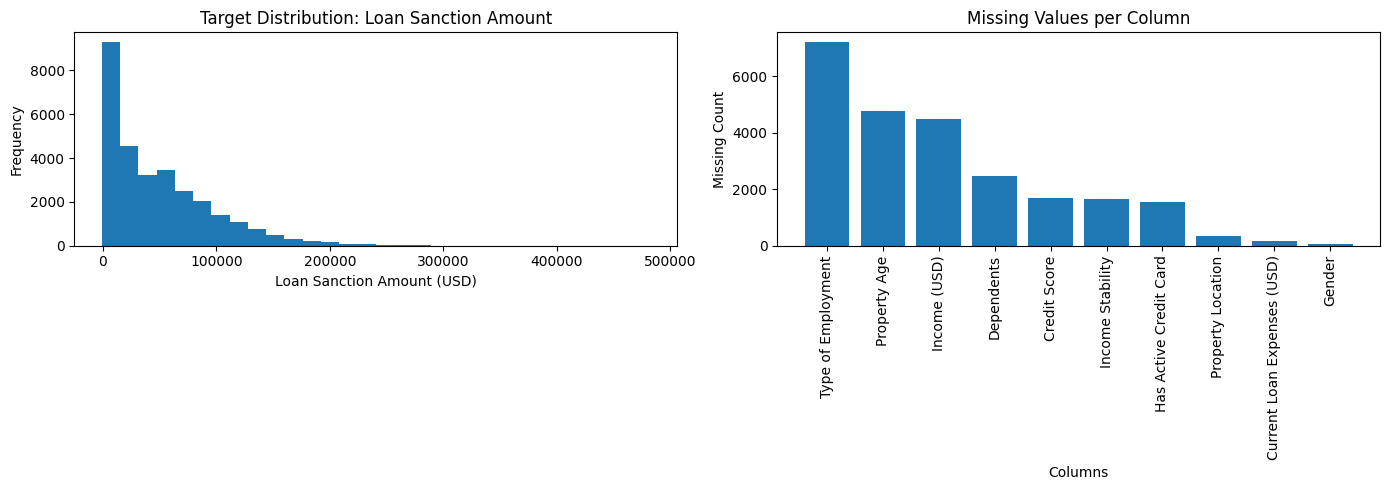

In [167]:
TARGET_COL = "Loan Sanction Amount (USD)"

fig, ax = plt.subplots(1, 2, figsize=(14, 5))


ax[0].hist(train_df[TARGET_COL], bins=30)
ax[0].set_title("Target Distribution: Loan Sanction Amount")
ax[0].set_xlabel("Loan Sanction Amount (USD)")
ax[0].set_ylabel("Frequency")

# (2) Missing values bar chart
missing = train_df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]  # only missing columns

ax[1].bar(missing.index, missing.values)
ax[1].set_title("Missing Values per Column")
ax[1].set_xlabel("Columns")
ax[1].set_ylabel("Missing Count")
ax[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


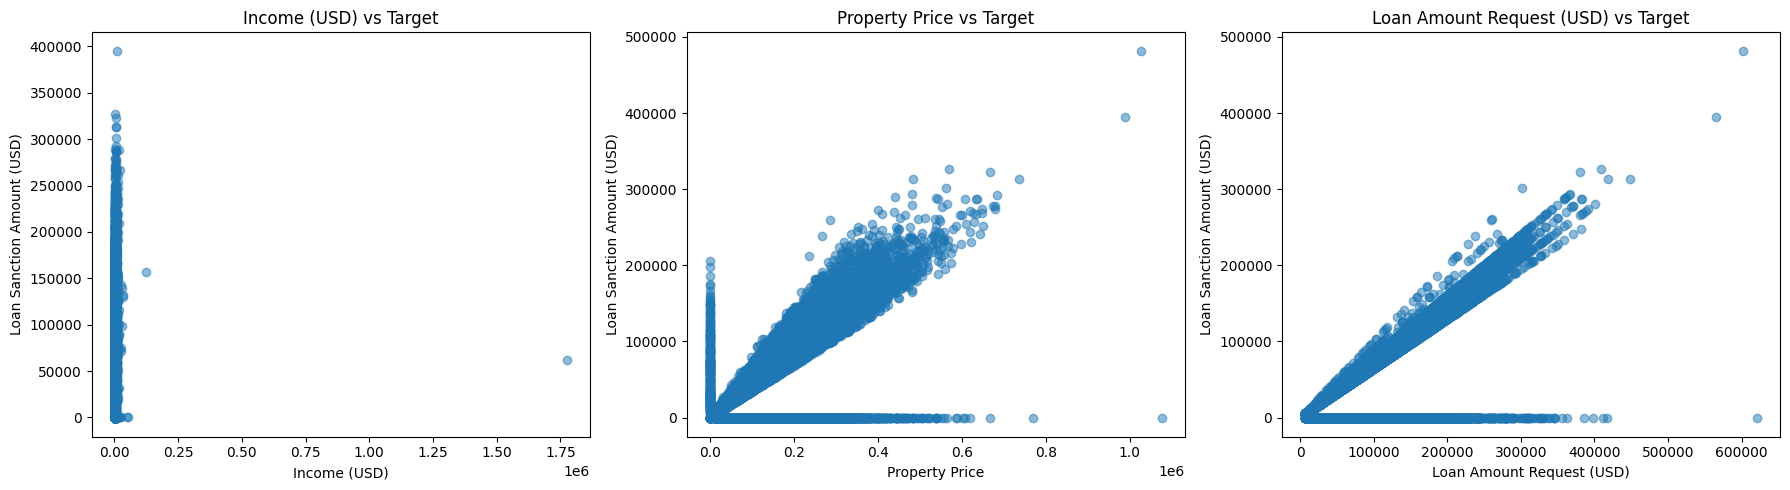

In [168]:
important_cols = ["Income (USD)", "Property Price", "Loan Amount Request (USD)"]

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(important_cols):
    ax[i].scatter(train_df[col], train_df[TARGET_COL], alpha=0.5)
    ax[i].set_title(f"{col} vs Target")
    ax[i].set_xlabel(col)
    ax[i].set_ylabel(TARGET_COL)

plt.tight_layout()
plt.show()


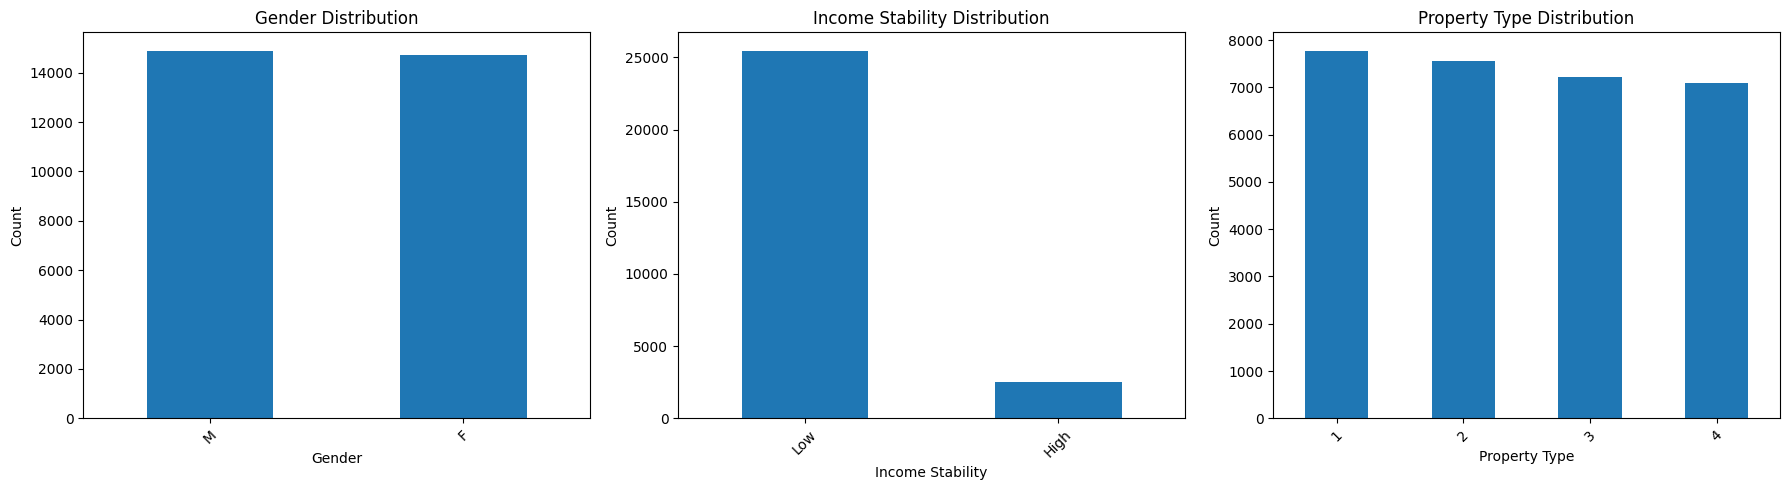

In [169]:
cat_cols_to_plot = ["Gender", "Income Stability", "Property Type"]

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols_to_plot):
    train_df[col].value_counts().plot(kind="bar", ax=ax[i])
    ax[i].set_title(f"{col} Distribution")
    ax[i].set_xlabel(col)
    ax[i].set_ylabel("Count")
    ax[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


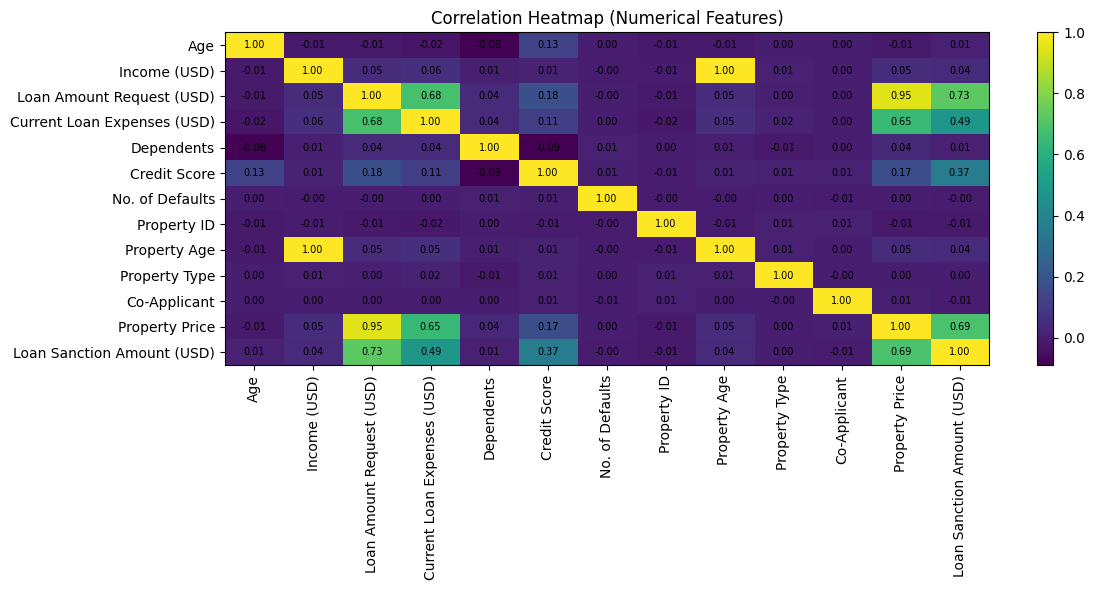

In [170]:
import numpy as np
import matplotlib.pyplot as plt


num_df = train_df.select_dtypes(include=["int64", "float64"])
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(12, 6))

cax = ax.imshow(corr, aspect="auto")
fig.colorbar(cax)


ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

ax.set_title("Correlation Heatmap (Numerical Features)")


for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()


Strong correlations with Target (Loan Sanction Amount)

  Loan Amount Request (USD) → 0.73 (strong positive)
  Property Price → 0.69 (strong positive)
  Current Loan Expenses → 0.49 (moderate)
  Credit Score → 0.37 (weak/moderate)


Weak / negligible correlations
  Age, Income, Dependents, Defaults → almost 0

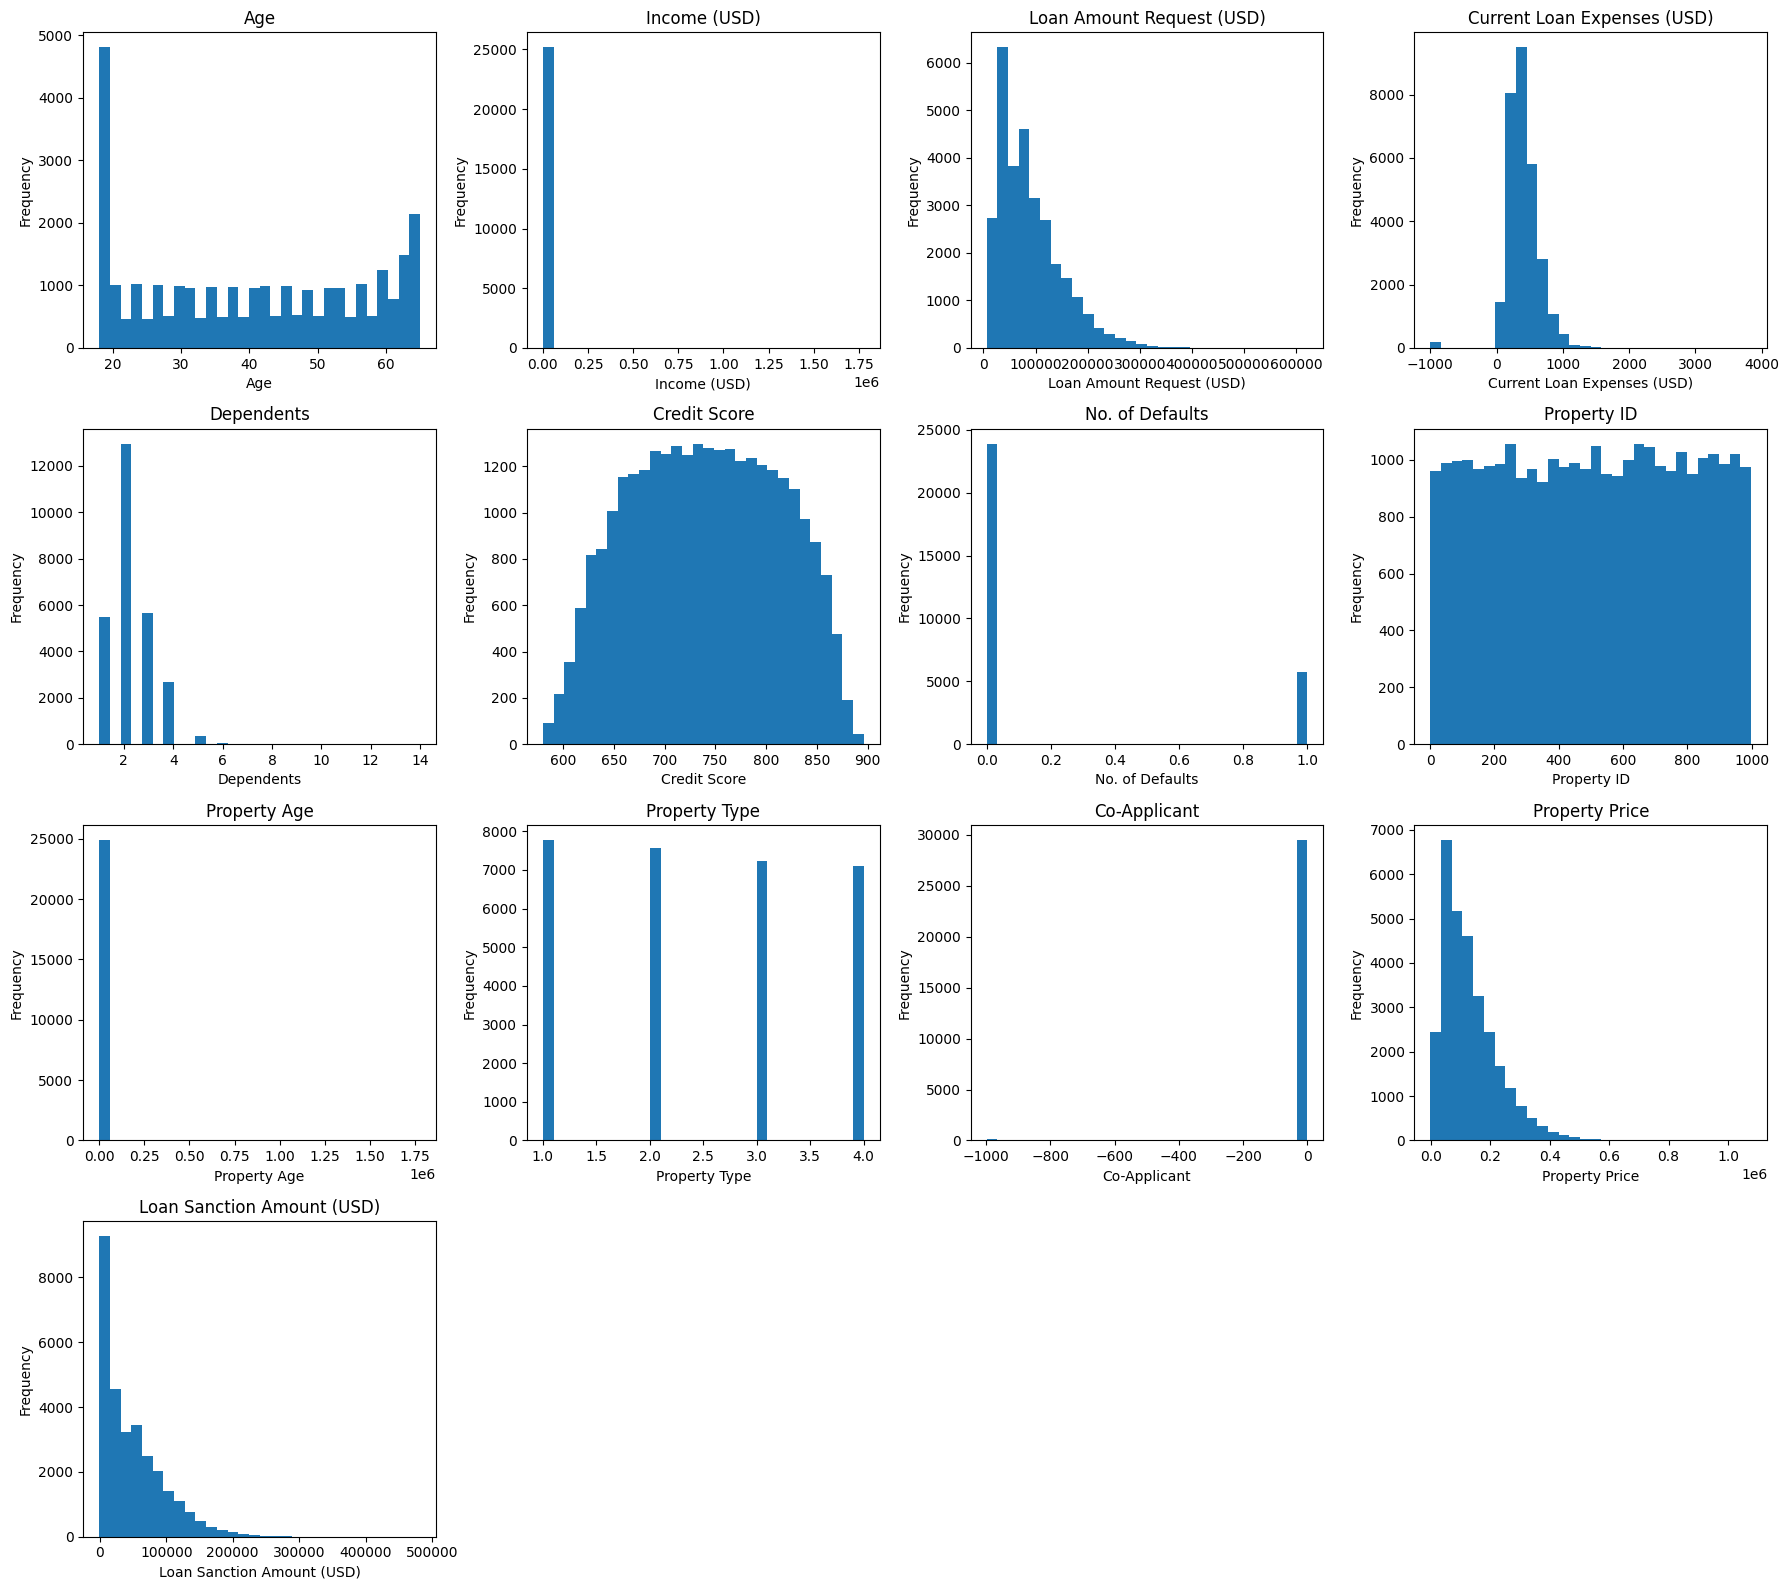

In [171]:
num_cols_all = train_df.select_dtypes(include=["int64", "float64"]).columns

n_cols = 4
n_rows = math.ceil(len(num_cols_all) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols_all):
    axes[i].hist(train_df[col].dropna(), bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")


for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

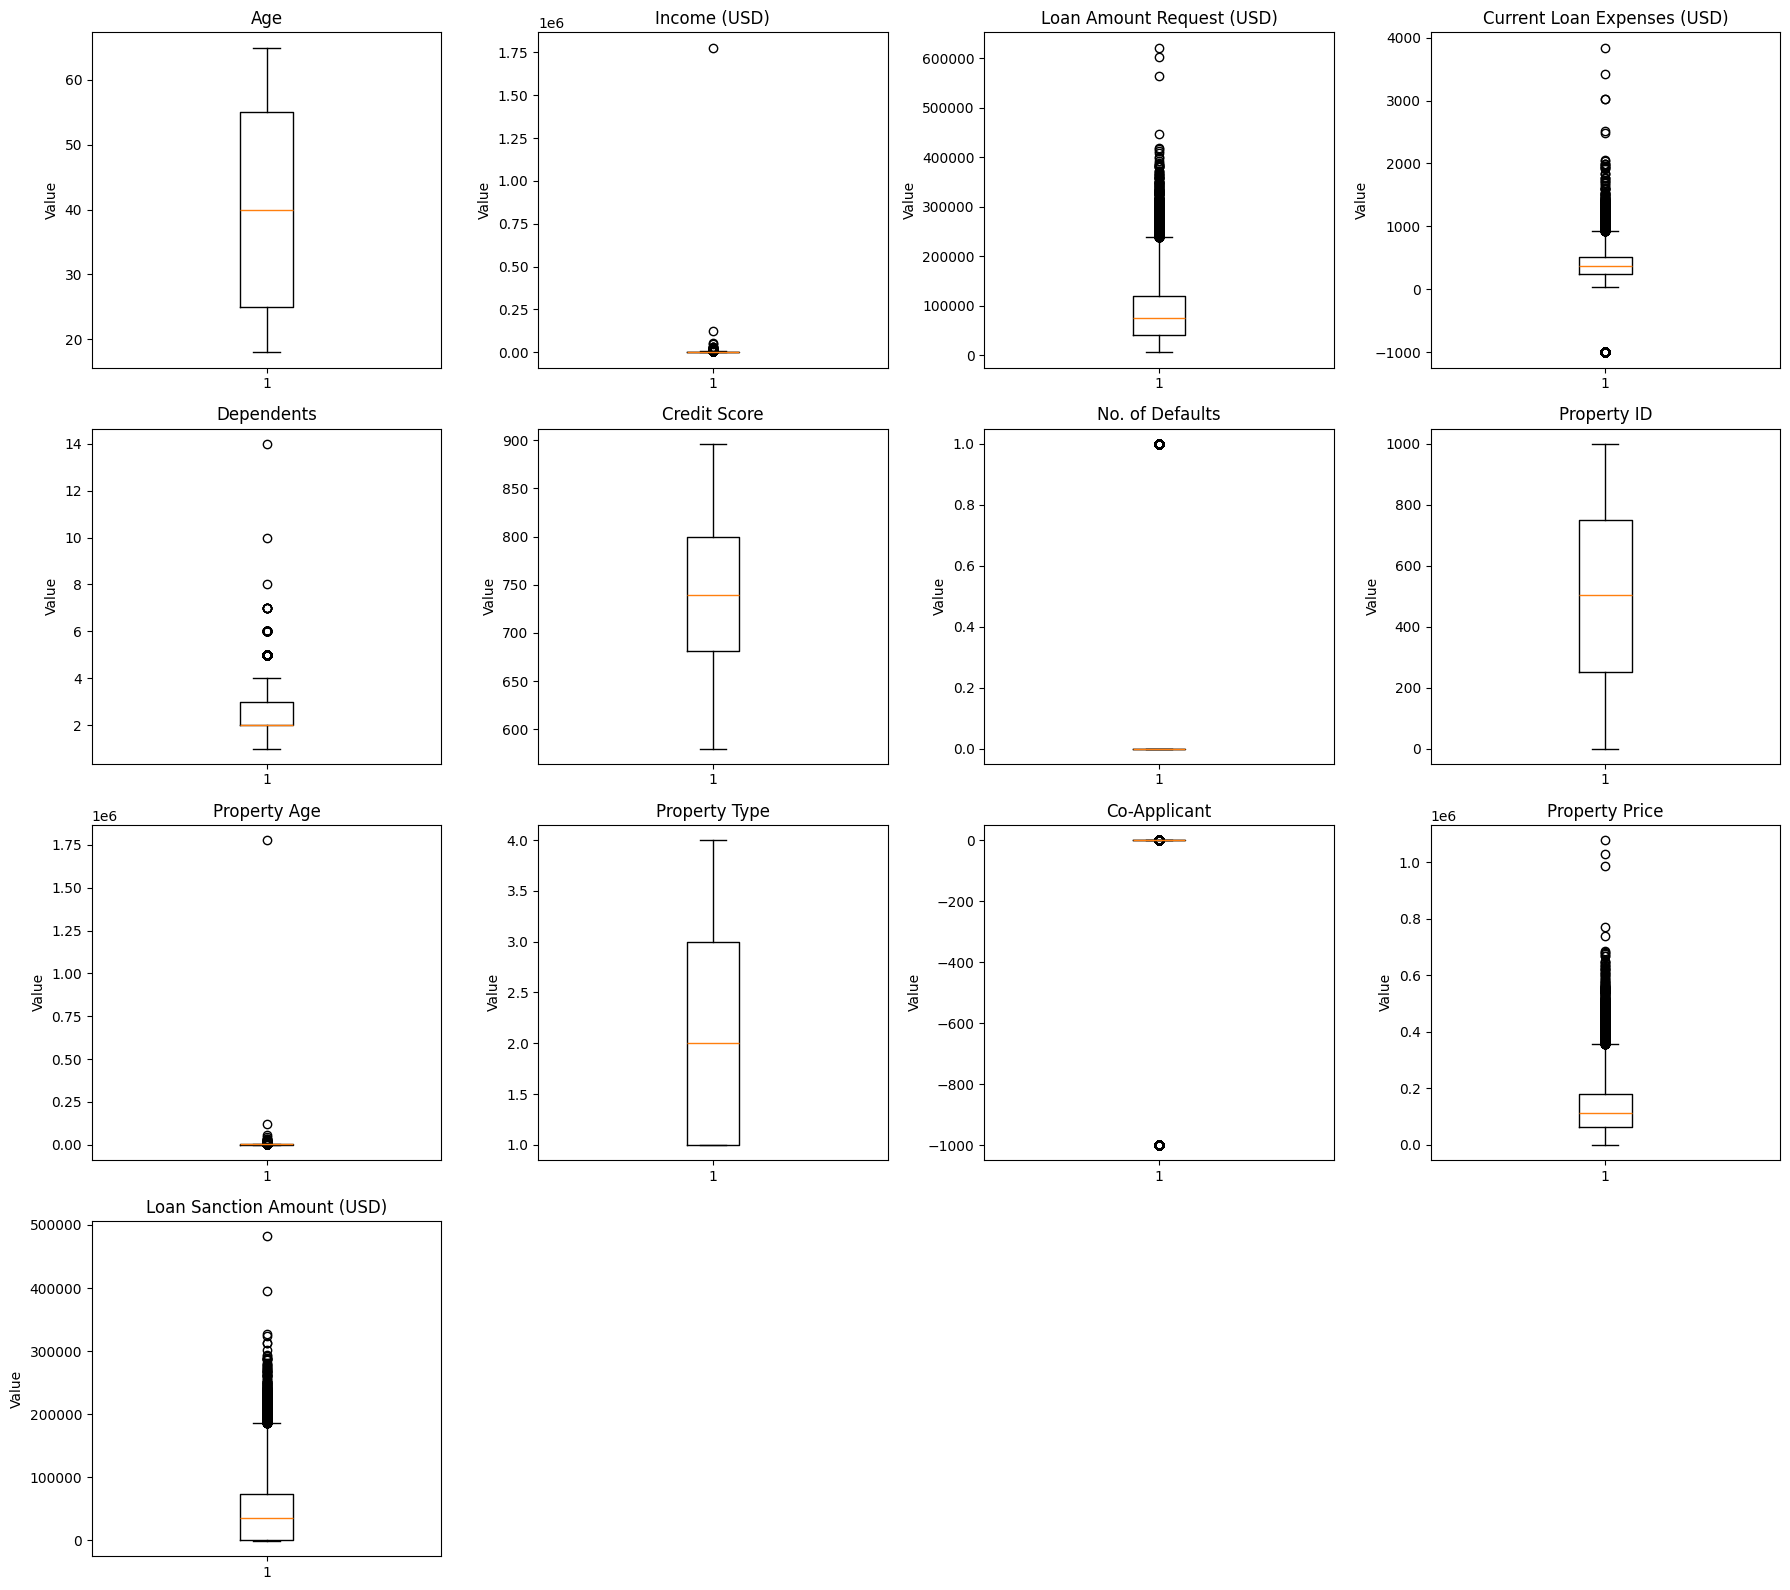

In [172]:
num_cols_all = train_df.select_dtypes(include=["int64", "float64"]).columns

n_cols = 4
n_rows = math.ceil(len(num_cols_all) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols_all):
    axes[i].boxplot(train_df[col].dropna(), vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [173]:
linear_model = Pipeline(steps=[("preprocessor",preprocessor2),("model",LinearRegression())])
linear_model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [174]:
y_pred_lr=linear_model.predict(X_val)

In [175]:
mae_lr = mean_absolute_error(y_val,y_pred_lr)
mse_lr = mean_squared_error(y_val,y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_val,y_pred_lr)

print("Linear Regression Results")
print("MAE:",mae_lr)
print("MSE:",mse_lr)
print("RMSE:",rmse_lr)
print("R2:",r2_lr)

Linear Regression Results
MAE: 21589.123325056713
MSE: 1018934379.7356938
RMSE: 31920.75155342828
R2: 0.5510856453401336


In [176]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import numpy as np

# 1. Create the SVR Pipeline
# We use the SAME preprocessor (preprocessor2) to ensure data is scaled identically.
# C=1.0: Regularization parameter (Like 'alpha' in Ridge, but inverse. Higher C = stricter).
# epsilon=0.1: The size of the "tube" where errors are ignored.
svr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("model", SVR(kernel="rbf", C=1.0, epsilon=0.1)) 
])

print("Training SVR Model... (This may take a minute due to dataset size)")
svr_pipeline.fit(X_train, y_train)

# 2. Predict
y_pred_svr = svr_pipeline.predict(X_val)

# 3. Evaluate SVR
mae_svr = mean_absolute_error(y_val, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_val, y_pred_svr))
r2_svr = r2_score(y_val, y_pred_svr)

print("\nSupport Vector Regressor Results:")
print(f"MAE:  ${mae_svr:,.2f}")
print(f"RMSE: ${rmse_svr:,.2f}")
print(f"R2:   {r2_svr:.4f}")

Training SVR Model... (This may take a minute due to dataset size)

Support Vector Regressor Results:
MAE:  $36,560.94
RMSE: $48,782.91
R2:   -0.0485


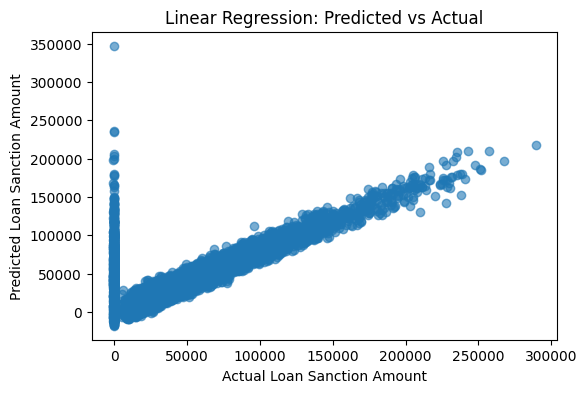

In [177]:
plt.figure(figsize=(6,4))
plt.scatter(y_val, y_pred_lr, alpha=0.6)
plt.title("Linear Regression: Predicted vs Actual")
plt.xlabel("Actual Loan Sanction Amount")
plt.ylabel("Predicted Loan Sanction Amount")
plt.show()

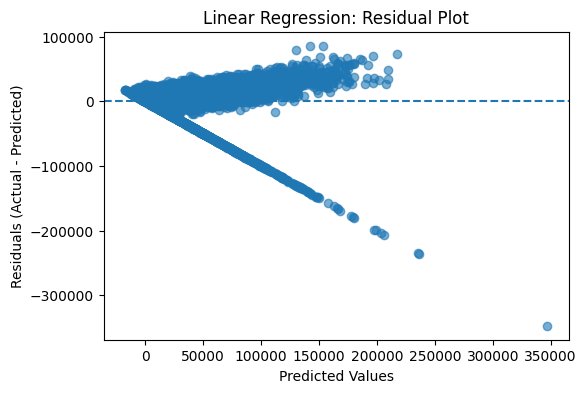

In [178]:
residuals = y_val - y_pred_lr

plt.figure(figsize=(6,4))
plt.scatter(y_pred_lr, residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")
plt.title("Linear Regression: Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.show()


Step 6 — Ridge Regression (L2 Regularization)

In [179]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_val)

mae_ridge = mean_absolute_error(y_val, y_pred_ridge)
mse_ridge = mean_squared_error(y_val, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_val, y_pred_ridge)

print("Ridge Regression (alpha=1.0) Results")
print("MAE :", mae_ridge)
print("MSE :", mse_ridge)
print("RMSE:", rmse_ridge)
print("R²  :", r2_ridge)

Ridge Regression (alpha=1.0) Results
MAE : 21583.232537696207
MSE : 1018769658.143722
RMSE: 31918.171284453656
R²  : 0.551158217125549


In [180]:
ridge_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("model", Ridge())
])

param_grid_ridge = {
    "model__alpha": [0.01, 0.1, 1, 10, 50, 100, 200]
}

grid_ridge = GridSearchCV(
    ridge_pipe,
    param_grid_ridge,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_ridge.fit(X_train, y_train)

print("Best Ridge Alpha:", grid_ridge.best_params_)
print("Best CV R² Score:", grid_ridge.best_score_)


Best Ridge Alpha: {'model__alpha': 200}
Best CV R² Score: 0.5697552432555927


In [181]:
best_ridge = grid_ridge.best_estimator_
y_pred_best_ridge = best_ridge.predict(X_val)

mae_best_ridge = mean_absolute_error(y_val, y_pred_best_ridge)
mse_best_ridge = mean_squared_error(y_val, y_pred_best_ridge)
rmse_best_ridge = np.sqrt(mse_best_ridge)
r2_best_ridge = r2_score(y_val, y_pred_best_ridge)

print("Best Ridge Model Validation Results")
print("MAE :", mae_best_ridge)
print("MSE :", mse_best_ridge)
print("RMSE:", rmse_best_ridge)
print("R²  :", r2_best_ridge)


Best Ridge Model Validation Results
MAE : 21597.405461435927
MSE : 1016609477.8431191
RMSE: 31884.31397792838
R²  : 0.5521099329228369


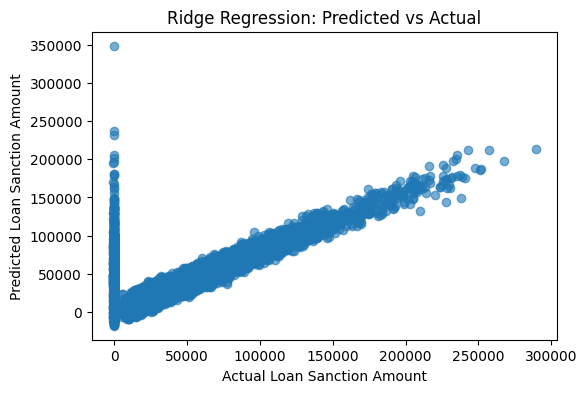

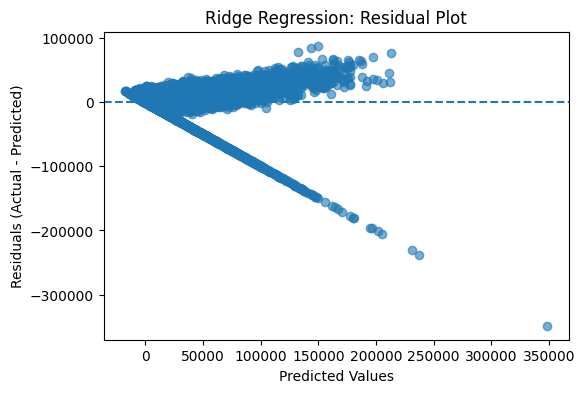

In [182]:
plt.figure(figsize=(6,4))
plt.scatter(y_val, y_pred_best_ridge, alpha=0.6)
plt.title("Ridge Regression: Predicted vs Actual")
plt.xlabel("Actual Loan Sanction Amount")
plt.ylabel("Predicted Loan Sanction Amount")
plt.show()


residuals_ridge = y_val - y_pred_best_ridge

plt.figure(figsize=(6,4))
plt.scatter(y_pred_best_ridge, residuals_ridge, alpha=0.6)
plt.axhline(y=0, linestyle="--")
plt.title("Ridge Regression: Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.show()


Step 7 — Lasso Regression (L1 Regularization)

In [183]:
drop_cols = ["Customer ID", "Name", "Property ID"]
X_train2 = X_train.drop(columns=drop_cols, errors="ignore")
X_val2   = X_val.drop(columns=drop_cols, errors="ignore")

lasso_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("model", Lasso(max_iter=1000, tol=1e-2))
])

param_grid_lasso = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]   # ✅ PDF grid
}

grid_lasso = GridSearchCV(
    lasso_pipe,
    param_grid_lasso,
    cv=3,           # change to 5 if required strictly
    scoring="r2",
    n_jobs=-1
)

grid_lasso.fit(X_train2, y_train)

best_lasso = grid_lasso.best_estimator_
y_pred_best_lasso = best_lasso.predict(X_val2)

mae = mean_absolute_error(y_val, y_pred_best_lasso)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_best_lasso))
r2 = r2_score(y_val, y_pred_best_lasso)

print("✅ Best Lasso Params:", grid_lasso.best_params_)
print("✅ MAE:", mae)
print("✅ RMSE:", rmse)
print("✅ R²:", r2)


✅ Best Lasso Params: {'model__alpha': 10}
✅ MAE: 21563.904753320432
✅ RMSE: 31902.517027276266
✅ R²: 0.5515983777863149


In [ ]:
lasso_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor2
     ),
    ("model", Lasso(max_iter=1000))
])

param_grid_lasso = {
    "model__alpha": [0.01,0.1,1,10,100]
}

grid_lasso = GridSearchCV(
    lasso_pipe,
    param_grid_lasso,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_lasso.fit(X_train, y_train)

print("Best Lasso Alpha:", grid_lasso.best_params_)
print("Best CV R² Score:", grid_lasso.best_score_)


In [ ]:
best_lasso = grid_lasso.best_estimator_
y_pred_best_lasso = best_lasso.predict(X_val)

mae_best_lasso = mean_absolute_error(y_val, y_pred_best_lasso)
mse_best_lasso = mean_squared_error(y_val, y_pred_best_lasso)
rmse_best_lasso = np.sqrt(mse_best_lasso)
r2_best_lasso = r2_score(y_val, y_pred_best_lasso)

print("Best Lasso Model Validation Results")
print("MAE :", mae_best_lasso)
print("MSE :", mse_best_lasso)
print("RMSE:", rmse_best_lasso)
print("R²  :", r2_best_lasso)


Best Lasso Model Validation Results
MAE : 21571.720376741465
MSE : 1015886416.8299698
RMSE: 31872.973140734295
R²  : 0.5524284936413218


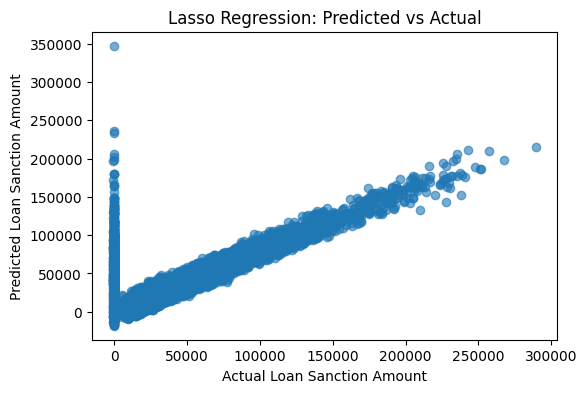

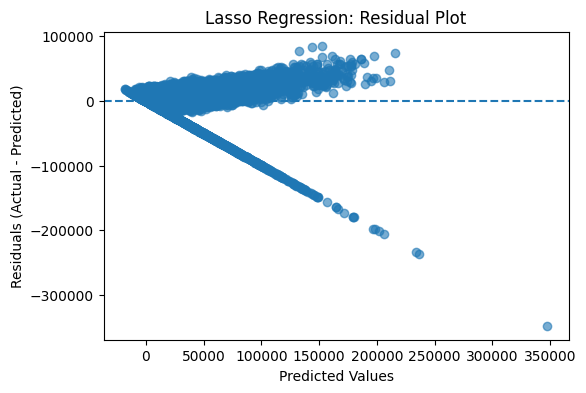

In [ ]:
# Predicted vs Actual
plt.figure(figsize=(6,4))
plt.scatter(y_val, y_pred_best_lasso, alpha=0.6)
plt.title("Lasso Regression: Predicted vs Actual")
plt.xlabel("Actual Loan Sanction Amount")
plt.ylabel("Predicted Loan Sanction Amount")
plt.show()

# Residual Plot
residuals_lasso = y_val - y_pred_best_lasso

plt.figure(figsize=(6,4))
plt.scatter(y_pred_best_lasso, residuals_lasso, alpha=0.6)
plt.axhline(y=0, linestyle="--")
plt.title("Lasso Regression: Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.show()


In [ ]:
lasso_final = best_lasso.named_steps["model"]
zero_coefs = np.sum(lasso_final.coef_ == 0)

print("Total coefficients:", len(lasso_final.coef_))
print("Zero coefficients (features removed):", zero_coefs)


Total coefficients: 53
Zero coefficients (features removed): 38


Step 8 — Elastic Net Regression (L1 + L2 Regularization)

In [ ]:
elastic_model = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("model", ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000))
])

elastic_model.fit(X_train, y_train)
y_pred_elastic = elastic_model.predict(X_val)

mae_elastic = mean_absolute_error(y_val, y_pred_elastic)
mse_elastic = mean_squared_error(y_val, y_pred_elastic)
rmse_elastic = np.sqrt(mse_elastic)
r2_elastic = r2_score(y_val, y_pred_elastic)

print("ElasticNet (alpha=1.0, l1_ratio=0.5) Results")
print("MAE :", mae_elastic)
print("MSE :", mse_elastic)
print("RMSE:", rmse_elastic)
print("R²  :", r2_elastic)

ElasticNet (alpha=1.0, l1_ratio=0.5) Results
MAE : 23039.91246382238
MSE : 1066356959.0723671
RMSE: 32655.12148304408
R²  : 0.5301925662345379


In [ ]:
elastic_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("model", ElasticNet(max_iter=5000))
])

param_grid_elastic = {
    "model__alpha": [0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.2, 0.5, 0.8]
}

grid_elastic = GridSearchCV(
    elastic_pipe,
    param_grid_elastic,
    cv=3,            # reduced CV for speed
    scoring="r2",
    n_jobs=-1
)

grid_elastic.fit(X_train, y_train)

print("Best ElasticNet Params:", grid_elastic.best_params_)
print("Best CV R² Score:", grid_elastic.best_score_)


Best ElasticNet Params: {'model__alpha': 1, 'model__l1_ratio': 0.8}
Best CV R² Score: 0.5715695591425846


In [ ]:
best_elastic = grid_elastic.best_estimator_
y_pred_best_elastic = best_elastic.predict(X_val)

mae_best_elastic = mean_absolute_error(y_val, y_pred_best_elastic)
mse_best_elastic = mean_squared_error(y_val, y_pred_best_elastic)
rmse_best_elastic = np.sqrt(mse_best_elastic)
r2_best_elastic = r2_score(y_val, y_pred_best_elastic)

print("Best ElasticNet Validation Results")
print("MAE :", mae_best_elastic)
print("MSE :", mse_best_elastic)
print("RMSE:", rmse_best_elastic)
print("R²  :", r2_best_elastic)


Best ElasticNet Validation Results
MAE : 22197.758830987383
MSE : 1032247714.3506986
RMSE: 32128.612082545653
R²  : 0.5452201576935043


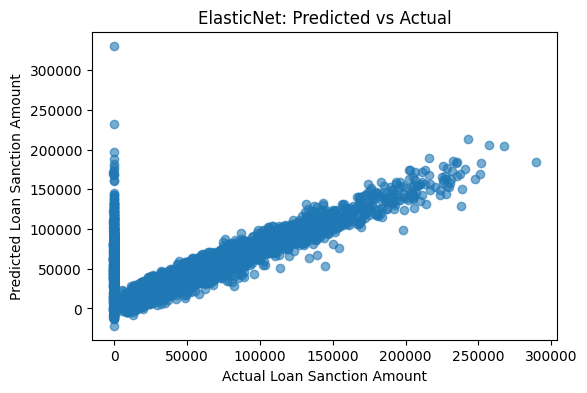

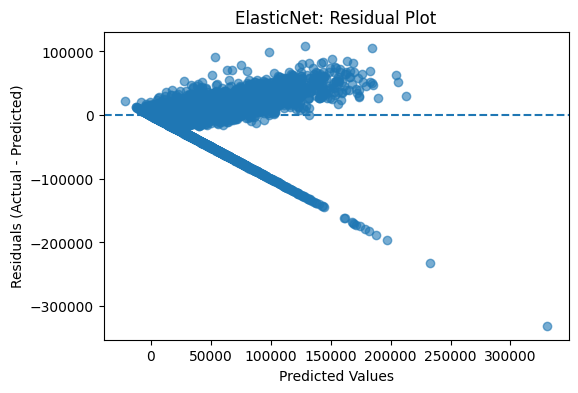

In [ ]:
# Predicted vs Actual
plt.figure(figsize=(6,4))
plt.scatter(y_val, y_pred_best_elastic, alpha=0.6)
plt.title("ElasticNet: Predicted vs Actual")
plt.xlabel("Actual Loan Sanction Amount")
plt.ylabel("Predicted Loan Sanction Amount")
plt.show()

# Residual Plot
residuals_elastic = y_val - y_pred_best_elastic

plt.figure(figsize=(6,4))
plt.scatter(y_pred_best_elastic, residuals_elastic, alpha=0.6)
plt.axhline(y=0, linestyle="--")
plt.title("ElasticNet: Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.show()

Best Lasso Params (your tuning)

You got:

Best alpha = 100 (CV R² = 0.5757)

Validation:

MAE = 21571.72

RMSE = 31872.97

R² = 0.55243

Compared to Linear (R²=0.55119), this is a small improvement.
Lasso Feature Selection Output (Very important)

Total coefficients = 53

Zero coefficients = 38

That means Lasso removed 38 features automatically.

ElasticNet Regression (Final Summary)
ElasticNet Base (alpha=1, l1_ratio=0.5)

MAE = 23039.91

RMSE = 32655.12

R² = 0.53019 ((worse))

Best ElasticNet Params (GridSearchCV)

alpha = 1

l1_ratio = 0.8

Best CV R² = 0.57157

Validation:

MAE = 22197.76

RMSE = 32128.61

R² = 0.54522

So ElasticNet performed slightly worse than Linear/Ridge/Lasso on validation.

| Model                               |          MAE |         RMSE |          R² |
| ----------------------------------- | -----------: | -----------: | ----------: |
| Linear Regression                   |     21579.76 |     31917.10 |     0.55119 |
| Ridge (Best α=200)                  |     21597.45 |     31884.06 |     0.55212 |
|(good)Lasso (Best α=100)                | **21571.72** | **31872.97** | **0.55243** |
| ElasticNet (Best α=1, l1_ratio=0.8) |     22197.76 |     32128.61 |     0.54522 |
| LassoLars                           |     17744.71 |     36016.64 |     0.42849 |


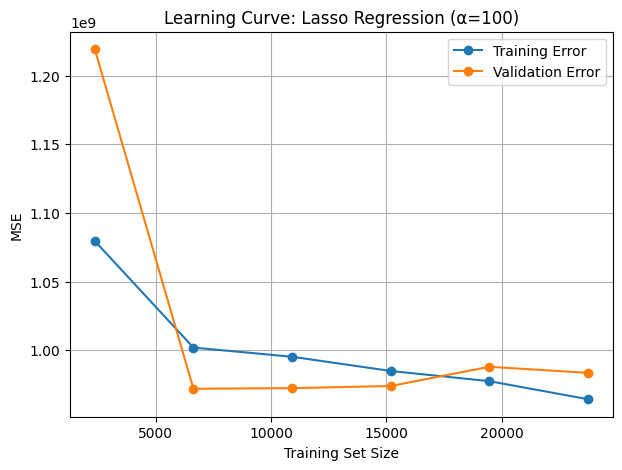

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X, y,
        cv=5,
        scoring="neg_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 6),
        n_jobs=-1
    )

    train_mse = -train_scores.mean(axis=1)
    val_mse = -val_scores.mean(axis=1)

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_mse, marker="o")
    plt.plot(train_sizes, val_mse, marker="o")
    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel("MSE")
    plt.legend(["Training Error", "Validation Error"])
    plt.grid(True)
    plt.show()

# ✅ Use BEST model here (Lasso α=100) or Ridge
best_lasso_model = Pipeline([
    ("preprocessor", preprocessor2),
    ("model", Lasso(alpha=100, max_iter=1000, tol=1e-2))
])

plot_learning_curve(best_lasso_model, X, y, "Learning Curve: Lasso Regression (α=100)")


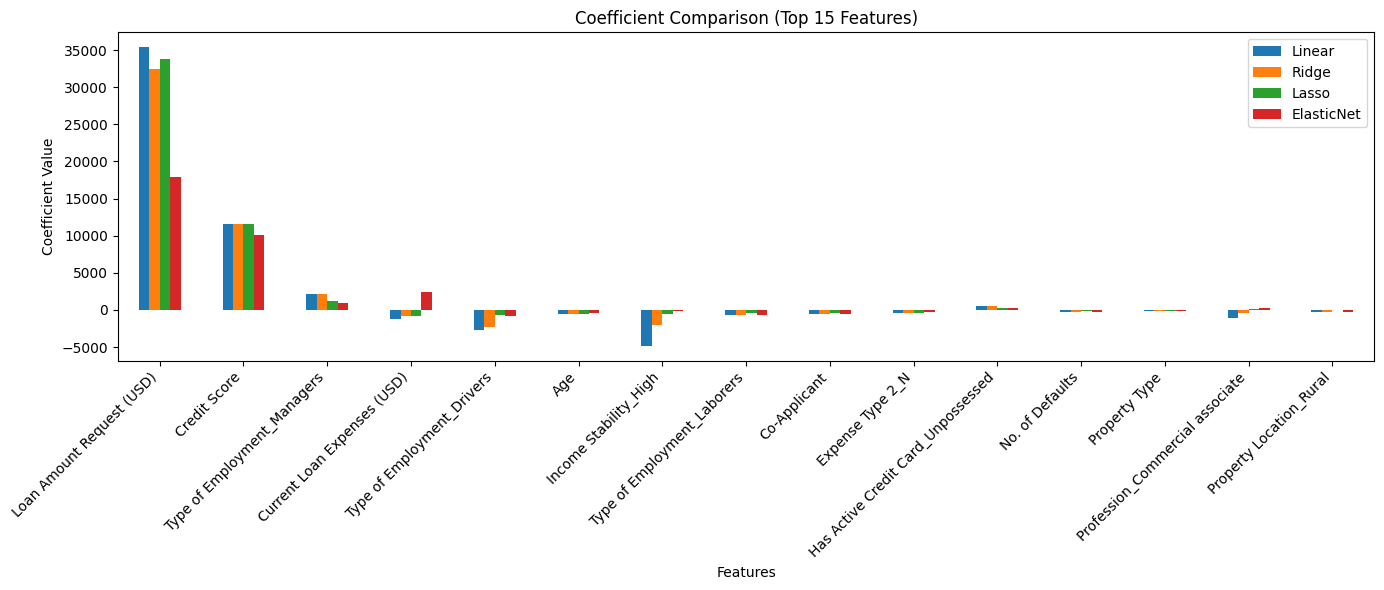

✅ Top coefficient comparison table:
                                          Linear         Ridge         Lasso  \
Loan Amount Request (USD)           35370.837982  32498.634276  33829.704637   
Credit Score                        11636.760990  11598.721950  11612.604939   
Type of Employment_Managers          2175.788260   2111.356541   1233.403707   
Current Loan Expenses (USD)         -1251.574593   -878.689088   -876.548751   
Type of Employment_Drivers          -2671.163033  -2292.845924   -696.520036   
Age                                  -610.586860   -572.035979   -586.473967   
Income Stability_High               -4821.076671  -2065.167989   -512.851010   
Type of Employment_Laborers          -742.251221   -658.817199   -466.552158   
Co-Applicant                         -510.887171   -521.960983   -421.058670   
Expense Type 2_N                     -421.950436   -421.022594   -400.055625   
Has Active Credit Card_Unpossessed    517.913566    497.820368    300.487014   
No. 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline

# ✅ Build final models using preprocessor2
linear_final = Pipeline([("preprocessor", preprocessor2), ("model", LinearRegression())])
ridge_final  = Pipeline([("preprocessor", preprocessor2), ("model", Ridge(alpha=200))])
lasso_final  = Pipeline([("preprocessor", preprocessor2), ("model", Lasso(alpha=100, max_iter=1000, tol=1e-2))])
elastic_final= Pipeline([("preprocessor", preprocessor2), ("model", ElasticNet(alpha=1, l1_ratio=0.8, max_iter=5000))])

models = {
    "Linear": linear_final,
    "Ridge": ridge_final,
    "Lasso": lasso_final,
    "ElasticNet": elastic_final
}

# ✅ Fit models
for name, m in models.items():
    m.fit(X_train2, y_train)

# ✅ Extract correct feature names after OneHotEncoding
ohe = preprocessor2.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_cols2)   # ✅ FIXED LINE

feature_names = np.concatenate([num_cols2, cat_feature_names])

# ✅ Extract coefficients
coef_dict = {}
for name, m in models.items():
    coef_dict[name] = m.named_steps["model"].coef_.reshape(-1)

coef_df = pd.DataFrame(coef_dict, index=feature_names)

# ✅ Pick top 15 based on Lasso magnitude
top_features = coef_df["Lasso"].abs().sort_values(ascending=False).head(15).index

# ✅ Plot coefficient comparison
coef_df.loc[top_features].plot(kind="bar", figsize=(14,6))
plt.title("Coefficient Comparison (Top 15 Features)")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("✅ Top coefficient comparison table:")
print(coef_df.loc[top_features])


Final Step — Use Best Model to Predict on test.csv

In [ ]:
train_df = train_df.replace("?", np.nan)
test_df  = test_df.replace("?", np.nan)

In [ ]:
drop_cols = ["Customer ID", "Name", "Property ID"]

X_test2 = test_df.drop(columns=drop_cols, errors="ignore")


In [ ]:
X_full = pd.concat([X_train2, X_val2], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso

best_lasso_final = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("model", Lasso(alpha=100, max_iter=1000, tol=1e-2))
])

best_lasso_final.fit(X_full, y_full)

test_predictions = best_lasso_final.predict(X_test2)

print("Predictions shape:", test_predictions.shape)
print(test_predictions[:5])


Predictions shape: (20000,)
[85195.95502284 71689.31178718 77472.14721805 66417.17887268
 58123.47143477]


In [ ]:
submission = pd.DataFrame({
    "Customer ID": test_df["Customer ID"],
    "Loan Sanction Amount (USD)": test_predictions
})

submission.to_csv("submission.csv", index=False)
print("✅ submission.csv saved successfully")


✅ submission.csv saved successfully
